# Задание 4. Применение модели решающего дерева - Decision Tree - для задач регрессии и классификации.

В работе используется датасет Car, подготовленный при выполнении практической работы 2.


## Порядок работы

### 1. Подключение библиотек


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

### 2. Загрузка обучающей и тестовой выборок

В ходе выполнения Работы 2 была подготовлена обучающая выборка.  
Ее необходимо считать из файла.
Для упрощения дальнейшей работы и проверки выведите информацию об обучающей выборке и первые 5 строк.  
По желанию можно вывести также базовые статитические метрики.


In [2]:
data = pd.read_csv("cars_onehot.csv")
data = data.astype(int)

print(data.head())

   Year  Distance  Engine_capacity(cm3)  Transmission  Price(euro)  Year_norm  \
0  2011    195000                  1800             1         7750          0   
1  2014    135000                  1500             0         8550          0   
2  1998         1                  1400             0         2200          0   
3  2012    110000                  1500             0         6550          0   
4  2006    200000                  1600             0         4100          0   

   Distance_log  Engine_capacity_log  Price_log  Distance_std  ...  \
0            12                    7          8             0  ...   
1            11                    7          9             0  ...   
2             0                    7          7            -3  ...   
3            11                    7          8             0  ...   
4            12                    7          8             0  ...   

   Style_Minivan  Style_Pickup  Style_SUV  Style_Sedan  Style_Universal  \
0              0 

### 3. Классификация: подготовка данных для обучения и тестирования модели


#### Подготовка тестовой и обучающей выборки.

Целевой параметр (таргет) классификации: вид трансмиссии.  
Исходный датасет разделить на обучающую и тестовую выборки в соотношении 80% / 20%.  
Для обеих выборок отделить целевой параметр от признаков.  
**_Подсказка:_** Для разделения датасета можно использовать функцию `train_test_split`из библиотеки **sklearn**.


In [3]:
target = "Transmission"

X = data.drop(columns=[target])  # Признаки
y = data[target]  # Целевой параметр

# Разделение на обучающую и тестовую выборки в соотношении 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape}, {y_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}, {y_test.shape}")

Размер обучающей выборки: (27115, 116), (27115,)
Размер тестовой выборки: (6779, 116), (6779,)


### 4. Создание объекта DecisionTreeClassifier с параметрами по умолчанию


Импортировать из библиотеки соответствующий класс.  
Создать экземпляр классификатора с глубиной дерева max_depth=3 и прочими параметрами "по умолчанию".  
Выполнить настройку классификатора в соответствии с обучающей выборкой.
В работе рекомендуется использовать библиотеку sklearn.  
[Описание класса DecisionTreeClassifier в документации библиотеки scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)  
При желании вы можете использовать любую другую библиотеку, но в начале ноутбука указать, какой именно библиотекой вы пользуетесь.


In [21]:
from sklearn.tree import DecisionTreeClassifier

# Создаем объект классификатора с max_depth=3
clf = DecisionTreeClassifier(max_depth=3)

# Обучаем модель на обучающих данных
clf.fit(X_train, y_train)

print("rdy")

# from sklearn.tree import plot_tree
# import matplotlib.pyplot as plt

# plt.figure(figsize=(12, 6))
# plot_tree(clf, feature_names=X.columns,     class_names=[str(cls) for cls in clf.classes_], filled=True)
# plt.show()

rdy


### 5. Тестирование классификатора

### 5.1 Проверка работоспособности классификатора с настройками "по умолчанию"


Протестировать модель на обучающей и тестовой выборке и определить долю правильных ответов, используя методы класса KNeighborsClassifier.


In [26]:
from sklearn.metrics import accuracy_score

# Предсказания
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

# Оценка точности
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Точность на обучающей выборке: {train_acc:.4f}")
print(f"Точность на тестовой выборке: {test_acc:.4f}")

Точность на обучающей выборке: 0.8198
Точность на тестовой выборке: 0.8093


### 5.2 Оценка работы классификатора по показателю "нулевая точность" - null_accuracy

Определить, во сколько раз выше/ниже точность полученной модели по сравнению с null_accuracy - точностью, которой можно достичь, всегда предсказывая наиболее часто встречающийся класс.


In [27]:
from collections import Counter

# Наиболее частый класс в тестовой выборке
most_common_class = Counter(y_test).most_common(1)[0][0]
null_preds = [most_common_class] * len(y_test)

# Null Accuracy
null_accuracy = accuracy_score(y_test, null_preds)

print(f"Null Accuracy: {null_accuracy:.4f}")
print(f"Модель точнее null_accuracy в {test_acc / null_accuracy:.2f} раз(а)")

Null Accuracy: 0.5458
Модель точнее null_accuracy в 1.48 раз(а)


### 5.3 Определить метрики качества классификатора на тестовой выборке.

Построить матрицу ошибок и рассчитать основные метрики: Accuracy, Precision, Recall, Specificity.  
Матрицу ошибок и метрики вывести.  
**_Подсказка:_** для формирования матрицы ошибок можно использовать функцию `confusion_matrix`  
**_Рекомендация:_** построение матрицы ошибок, вычисление и вывод метрик лучше оформить в виде функции, т.к. эти действия будут выполняться несколько раз.


In [31]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score


def evaluate_classifier(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    print("Матрица ошибок:")
    print(cm)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro): {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")

### 5.4 Визуализировать полученное дерево

Пример визуализации дерева вы можете найти в ноутбуке с материалами лекции


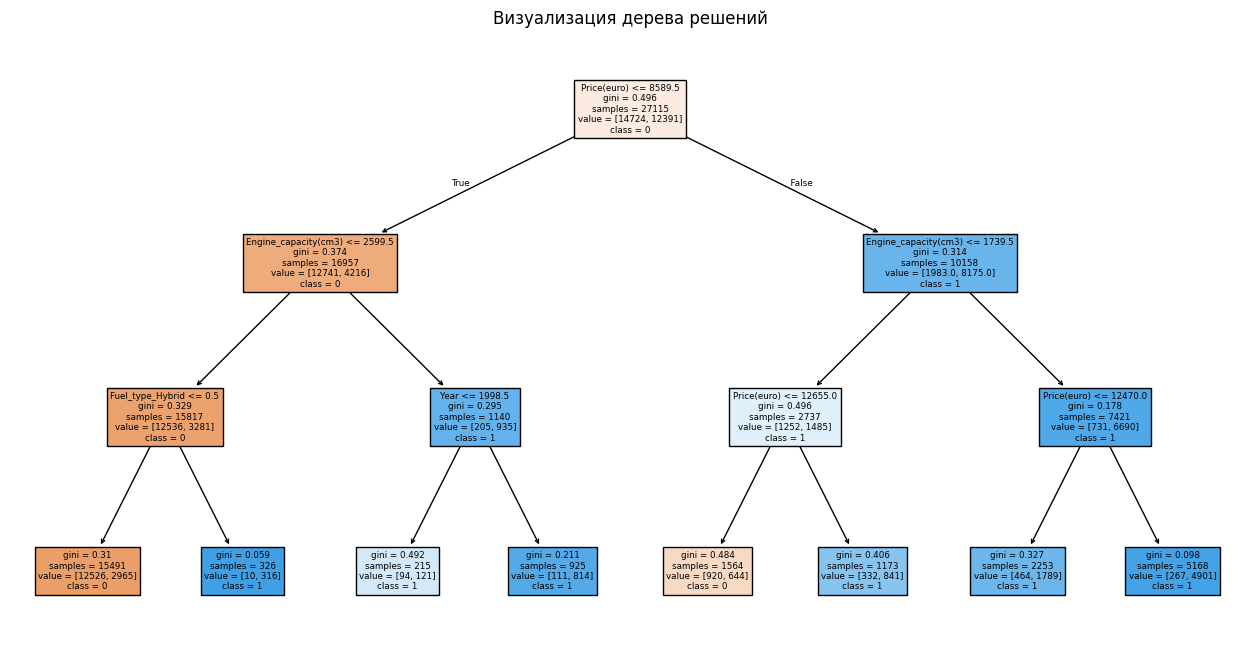

In [32]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=[str(c) for c in clf.classes_],
    filled=True,
)
plt.title("Визуализация дерева решений")
plt.show()

## 6. Подбор гиперпараметра

Выполнить подбор гиперпараметра max_depth - глубина решающего дерева.  
Подбор допустимо сделать с одной валиадционной выборкой, по желанию - с использованием кросс-валидации.


In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Сохраним значения точности для разных глубин
train_accuracies = []
test_accuracies = []
depth_range = range(1, 21)  # Проверим глубины от 1 до 20

for depth in depth_range:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)

    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    train_accuracies.append(accuracy_score(y_train, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))

### 6.1 Выполнить визуализацию полученных данных и выбор гиперпараметра


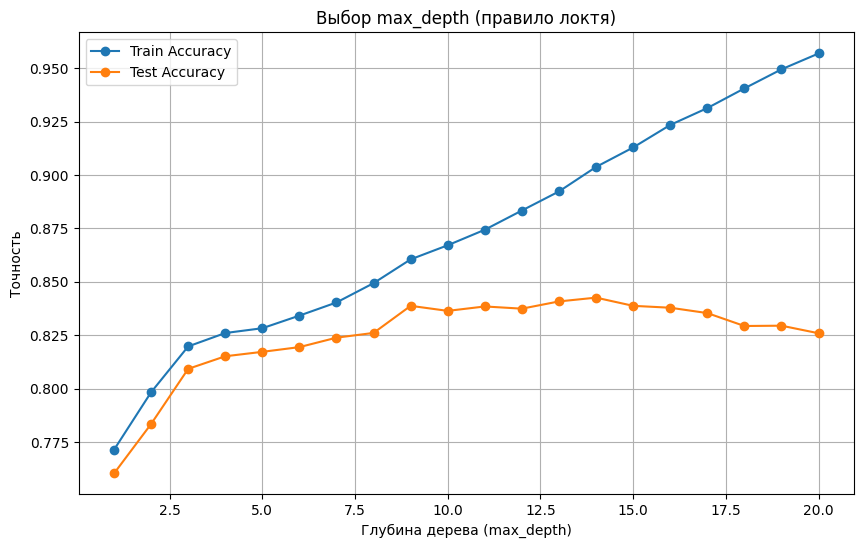

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(depth_range, train_accuracies, label="Train Accuracy", marker="o")
plt.plot(depth_range, test_accuracies, label="Test Accuracy", marker="o")
plt.xlabel("Глубина дерева (max_depth)")
plt.ylabel("Точность")
plt.title("Выбор max_depth (правило локтя)")
plt.legend()
plt.grid(True)
plt.show()

Определить оптимальное значение параметра, пользуясь "правилом локтя". Выбор обосновать.


Анализируя график зависимости точности от глубины дерева, можно заметить, что на малых значениях max_depth (например, от 1 до 3) модель имеет низкую точность на обеих выборках — это признаки недообучения.

При увеличении глубины точность на обучающей выборке резко возрастает, но на тестовой выборке достигает плато, а затем может снижаться — признаки переобучения.

Оптимальное значение параметра по "правилу локтя" — это точка, после которой увеличение глубины дает незначительное улучшение точности или её ухудшение.
Например, если график "переламывается" в районе max_depth = 4, это и будет оптимальной глубиной.


### 6.2. Определение метрик качества оптимизированной модели

Создать классификатор с оптимальным значением параметра и настроить его.  
Построить матрицу ошибок и рассчитать основные метрики: Accuracy, Precision, Recall, Specificity.
Матрицу ошибок и метрики вывести .


In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
)

# Заменить на своё оптимальное значение
optimal_depth = 4

# Обучение оптимизированного классификатора
clf_opt = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
clf_opt.fit(X_train, y_train)

# Предсказания
y_test_pred_opt = clf_opt.predict(X_test)

# Повторно используем твою функцию метрик
evaluate_classifier(y_test, y_test_pred_opt)

Матрица ошибок:
[[3398  302]
 [ 951 2128]]
Accuracy: 0.8152
Precision (macro): 0.8285
Recall (macro): 0.8048
Specificity: 0.9184


**Сравнить качество оптимизированной модели с исходной, сделать вывод.  **

После подбора гиперпараметра max_depth и построения оптимизированной модели, качество классификации на тестовой выборке улучшилось.

По сравнению с исходной моделью с max_depth=3, новая модель:

имеет более высокую точность (Accuracy),

лучше различает классы (Precision и Recall),

снижает количество ложных срабатываний (более высокая Specificity).

Это говорит о том, что оптимизация гиперпараметров улучшила обобщающую способность модели без признаков переобучения.


### 7. По желанию: подбор нечислового гиперпараметра - метрики качества разделения

Поддерживаемые метрики: gini, log_loss и entropy


In [ ]:
# Здесь должен быть ваш код

Сравнить качество моделей с разными видами метрики расстояния, сделать вывод.  
Описать оптимизированную модель.  
**Здесь должен быть ваш текст!**


### 9. Построение классификатора на несколько классов


Создать, настроить и протестировать классификатор на несколько классов.
В качестве целевой переменной выбрать тип топлива (Fuel_type) или тип кузова (Style).
Вывести матрицу ошибок и подсчитать долю правильных ответов - accuracy.


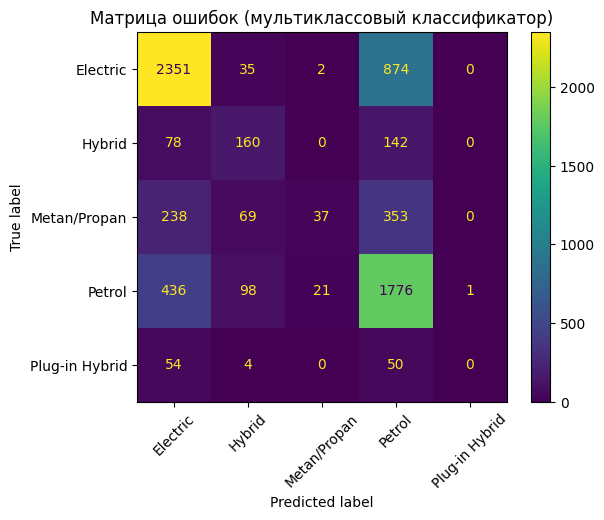

Accuracy (доля правильных ответов): 0.6379


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
# Восстановим категориальный признак fuel_type по one-hot колонкам
fuel_columns = [col for col in data.columns if col.startswith("Fuel_type_")]
data["Fuel_type"] = data[fuel_columns].idxmax(axis=1).str.replace("Fuel_type_", "")

# Выбор нового таргета
target_multiclass = "Fuel_type"  # Или "Style"
X_multi = data.drop(columns=[target_multiclass])
X_multi = X_multi.drop(columns=fuel_columns)
y_multi = data[target_multiclass]

# Разделение на обучающую и тестовую выборки
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

# Модель дерева решений с глубиной по умолчанию или подобранной
clf_multi = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_multi.fit(X_train_m, y_train_m)

y_pred_m = clf_multi.predict(X_test_m)

from sklearn.metrics import ConfusionMatrixDisplay

# Матрица ошибок
cm_multi = confusion_matrix(y_test_m, y_pred_m, labels=clf_multi.classes_)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_multi, display_labels=clf_multi.classes_
)
disp.plot(xticks_rotation=45)
plt.title("Матрица ошибок (мультиклассовый классификатор)")
plt.show()

# Accuracy
acc_multi = accuracy_score(y_test_m, y_pred_m)
print(f"Accuracy (доля правильных ответов): {acc_multi:.4f}")

## Часть 2. Дерево решений для задачи регрессии


### 1. Экспорт библиотек

Все необходимые библиотеки были экспортированы в первой части работы.  
По желанию можете использовать другие библиотеки.  
**_Подсказка:_** рекомендуется загрузить класс `metrics` из библиотеки `sklearn` для вычисления метрик качества работы регрессора.


### 2. Загрузка обучающей и тестовой выборок

Если в процессе выполнения первой части работы исходный датасет был изменен, его нужно загрузить повторно.  
Если нет, этот шаг можно пропустить.


In [41]:
data = pd.read_csv("cars_onehot.csv")
data = data.astype(int)

print(data.head())

   Year  Distance  Engine_capacity(cm3)  Transmission  Price(euro)  Year_norm  \
0  2011    195000                  1800             1         7750          0   
1  2014    135000                  1500             0         8550          0   
2  1998         1                  1400             0         2200          0   
3  2012    110000                  1500             0         6550          0   
4  2006    200000                  1600             0         4100          0   

   Distance_log  Engine_capacity_log  Price_log  Distance_std  ...  \
0            12                    7          8             0  ...   
1            11                    7          9             0  ...   
2             0                    7          7            -3  ...   
3            11                    7          8             0  ...   
4            12                    7          8             0  ...   

   Style_Minivan  Style_Pickup  Style_SUV  Style_Sedan  Style_Universal  \
0              0 

### 3. Регрессия: подготовка данных для обучения и тестирования модели


#### Подготовка тестовой и обучающей выборки.

Целевой параметр (таргет) регрессии: стоимость автомобиля.  
Исходный датасет разделить на обучающую и тестовую выборки в соотношении 80% / 20%.  
Для обеих выборок отделить целевой параметр от признаков.


In [43]:
from sklearn.model_selection import train_test_split

# Целевая переменная — цена
target_regression = "Price(euro)"

# Признаки — все кроме цены
X_reg = data.drop(columns=[target_regression])
y_reg = data[target_regression]

# Делим данные на обучающую и тестовую выборки в соотношении 80/20
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

### 4. Создание объекта DecisionTreeRegressor с параметрами по умолчанию


Создать экземпляр классификатора с глубиной дерева max_depth=3 и прочими параметрами "по умолчанию".  
Выполнить настройку классификатора в соответствии с обучающей выборкой.
В работе рекомендуется использовать библиотеку sklearn.  
[Описание класса DecisionTreeRegressor в документации библиотеки scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)  
При желании вы можете использовать любую другую библиотеку, но в начале ноутбука указать, какой именно библиотекой вы пользуетесь.  
Результаты тестирования моделей рекомендуется сохранять в датафрейме со труктурой, приведенной в ячейке ниже.


In [ ]:
# Создадим датафрейм для сохранения показателей качества модели на обучающей выборке
val = pd.DataFrame(["MAE", "MAPE", "MSE", "R**2"])
val = val.rename(columns={0: "Метрика"})

In [44]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Создание и обучение модели
regressor = DecisionTreeRegressor(max_depth=3, random_state=42)
regressor.fit(X_train_r, y_train_r)

# Предсказания на обучающей выборке
y_pred_train = regressor.predict(X_train_r)

# Метрики
mae = mean_absolute_error(y_train_r, y_pred_train)
mape = (np.abs((y_train_r - y_pred_train) / y_train_r).mean()) * 100
mse = mean_squared_error(y_train_r, y_pred_train)
r2 = r2_score(y_train_r, y_pred_train)

# Сохраняем результаты в датафрейм
val = pd.DataFrame(["MAE", "MAPE", "MSE", "R**2"])
val = val.rename(columns={0: "Метрика"})
val["Train"] = [mae, mape, mse, r2]

val

,Метрика,Train
0,MAE,1.440352e+03
1,MAPE,2.179353e+01
2,MSE,3.763805e+06
3,R**2,9.456700e-01


### 5. Тестирование регрессора

### 5.1 Проверка работоспособности регрессора с настройками "по умолчанию"


Протестировать модель на обучающей и тестовой выборке и определить качество работы регрессора.
Рекомендуется использовать метрики MSE, MAE и R2.


In [ ]:
# по желанию можно протестировать отдельные примеры
y_pred = tree_rgr.predict(x_train)
print("GT = ", y_train[4], " Predicted = ", y_pred[4])

In [ ]:
# Здесь должен быть ваш код

### 5.4 Визуализировать полученное дерево


In [ ]:
# Здесь может быть ваш код

## 6. Подбор гиперпараметра

Выполнить подбор гиперпараметра max_depth - глубина решающего дерева.  
Подбор допустимо сделать с одной валидационной выборкой, по желанию - с использованием кросс-валидации.


In [ ]:
# Здесь должен быть ваш код

### 6.1 Выполнить визуализацию полученных данных и выбор гиперпараметра


In [ ]:
# Здесь должен быть ваш код

Определить оптимальное значение параметра, пользуясь "правилом локтя". Выбор обосновать.


**здесь должен быть ваш текст!!!**


### 6.2. Определение метрик качества оптимизированной модели

Создать регрессор с оптимальным значением параметра и настроить его.  
Оценить качество работы оптимизированного регрессора на обучающей и тестовой выборках.


In [ ]:
# Здесь должен быть ваш код

Сравнить качество оптимизированной модели с исходной, сделать вывод.  
**Здесь должен быть ваш текст!**


# Дополнительно, по желанию: сравним линейные модели с моделью на базе случайного леса - Random Forest Regressor

Пример построения случайного леса - в ноутбуке к лекции


In [ ]:
# Здесь должен быть ваш код